<a href="https://colab.research.google.com/github/brightliam20-ops/AVCAD-ASSIGNMENT/blob/main/Exercise7_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data_path = '/content/EFIplus_medit/EFIplus_medit.csv'
df = pd.read_csv(data_path, sep=';')

print("Dataset loaded successfully. Here are the first 5 rows:")
print(df.head())
print("\nAnd here is some basic information about the dataset:")
print(df.info())

Dataset loaded successfully. Here are the first 5 rows:
    Site_code   Latitude  Longitude Country Catchment_name  Galiza  Subsample  \
0  ES_01_0002  38.102003  -4.096070   Spain   Guadalquivir       0          1   
1  ES_02_0001  40.530188  -1.887796   Spain           Tejo       0          1   
2  ES_02_0002  40.595432  -1.928079   Spain           Tejo       0          1   
3  ES_02_0003  40.656184  -1.989831   Spain           Tejo       0          1   
4  ES_02_0004  40.676402  -2.036274   Spain           Tejo       0          1   

   Calib_EFI_Medit  Calib_connect  Calib_hydrol  ...  Squalius malacitanus  \
0                0              1             0  ...                     0   
1                1              1             1  ...                     0   
2                1              1             1  ...                     0   
3                1              1             1  ...                     0   
4                1              1             1  ...               


--- Distribution of 'Total_sp' ---


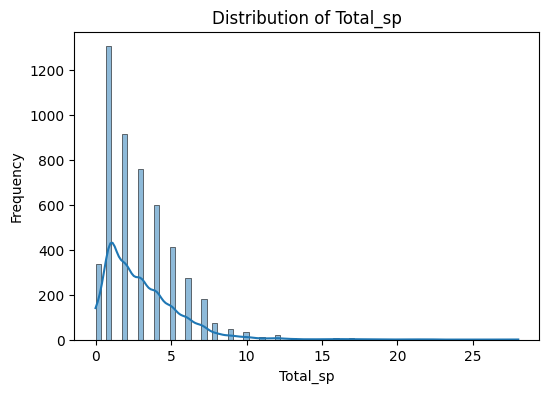


--- Distribution of 'Altitude' ---


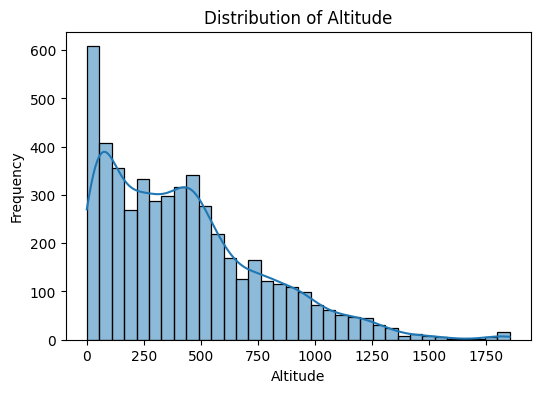


--- Distribution of 'Actual_river_slope' ---


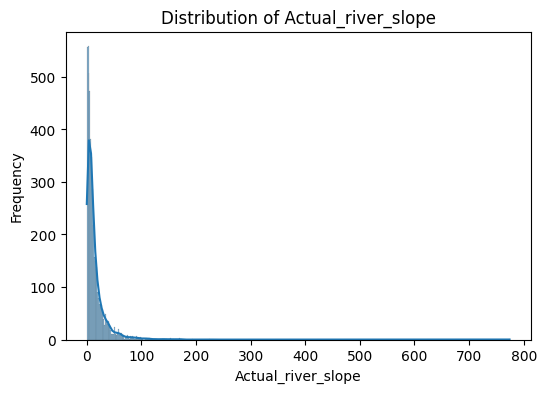


--- Distribution of 'Elevation_mean_catch' ---


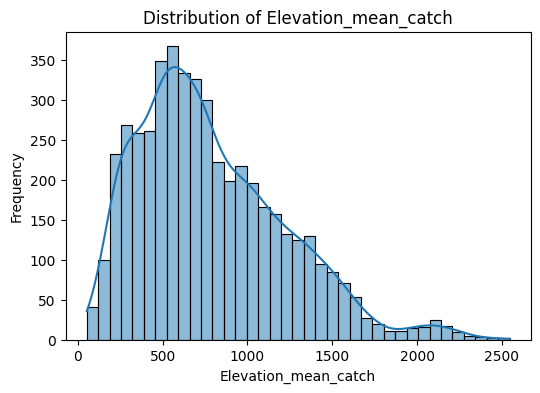


--- Distribution of 'prec_ann_catch' ---


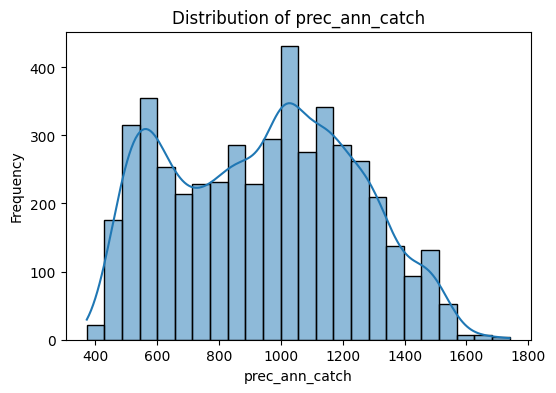


--- Distribution of 'temp_ann' ---


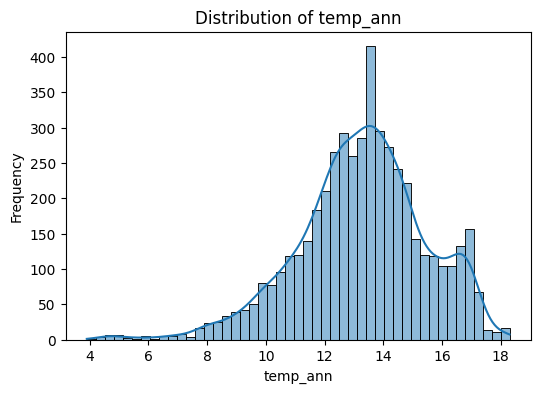


--- Distribution of 'temp_jan' ---


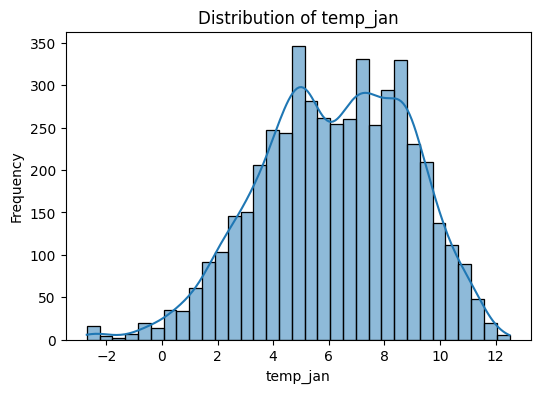


--- Distribution of 'temp_jul' ---


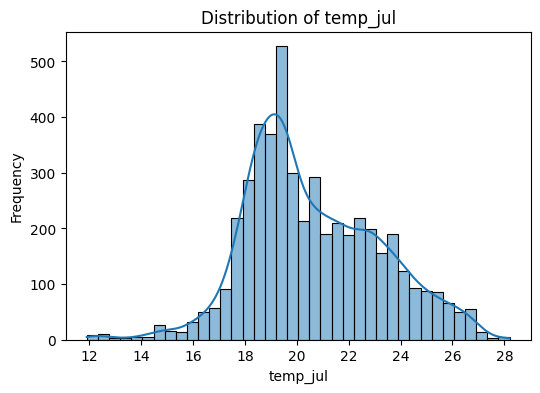

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the target variable (species richness) and continuous environmental variables
target_variable = 'Total_sp'
predictor_variables = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

# Check the distributions of the target and predictor variables
print(f"\n--- Distribution of '{target_variable}' ---")
plt.figure(figsize=(6, 4))
sns.histplot(df[target_variable], kde=True)
plt.title(f'Distribution of {target_variable}')
plt.xlabel(target_variable)
plt.ylabel('Frequency')
plt.show()

for col in predictor_variables:
    print(f"\n--- Distribution of '{col}' ---")
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    # Check for zero values, which would prevent log transformation
    if (df[col] <= 0).any():
        print(f"Warning: '{col}' contains non-positive values (<=0). Log transformation might not be directly applicable.")


In [ ]:
print("\n--- Further investigation of variable distributions and potential transformations ---")

# Investigate Total_sp
print(f"\nStatistics for {target_variable}:")
print(df[target_variable].describe())
print(f"Number of zeros in {target_variable}: {(df[target_variable] == 0).sum()}")

# Investigate predictor variables for transformation needs
for col in predictor_variables:
    print(f"\nStatistics for {col}:")
    print(df[col].describe())
    num_zeros = (df[col] == 0).sum()
    num_negative = (df[col] < 0).sum()
    print(f"Number of zeros in {col}: {num_zeros}")
    print(f"Number of negative values in {col}: {num_negative}")

# Apply transformations where appropriate
# Create a copy of the DataFrame to store transformed variables
df_transformed = df.copy()

# Target variable transformation: Species richness often benefits from log1p transformation
if (df_transformed[target_variable] >= 0).all(): # Ensure no negative values before log1p
    df_transformed[f'log_{target_variable}'] = np.log1p(df_transformed[target_variable])
    print(f"\nApplied log1p transformation to '{target_variable}'.")
else:
    print(f"Warning: '{target_variable}' contains negative values. log1p not applied.")

# Predictor variables transformations
transformed_predictors = []
for col in predictor_variables:
    # Check for non-positive values
    if (df_transformed[col] <= 0).any():
        # If zeros or negatives exist, use log1p or skip if negatives are problematic
        if (df_transformed[col] < 0).any():
            print(f"Warning: '{col}' contains negative values. Log transformation skipped for this variable. Consider other transformations if appropriate.")
            df_transformed[f'raw_{col}'] = df_transformed[col] # Keep original for regression
            transformed_predictors.append(f'raw_{col}')
        else: # Only zeros present
            df_transformed[f'log_{col}'] = np.log1p(df_transformed[col])
            print(f"Applied log1p transformation to '{col}'.")
            transformed_predictors.append(f'log_{col}')
    else: # All values are positive, can use np.log
        df_transformed[f'log_{col}'] = np.log(df_transformed[col])
        print(f"Applied log transformation to '{col}'.")
        transformed_predictors.append(f'log_{col}')

# Display head of transformed dataframe and info to confirm new columns
print("\nDataFrame with transformed variables:")
print(df_transformed[[f'log_{target_variable}'] + transformed_predictors].head())
print(df_transformed[[f'log_{target_variable}'] + transformed_predictors].info())



--- Further investigation of variable distributions and potential transformations ---

Statistics for Total_sp:
count    5011.000000
mean        3.024746
std         2.550055
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        28.000000
Name: Total_sp, dtype: float64
Number of zeros in Total_sp: 338

Statistics for Altitude:
count    5011.000000
mean      428.072042
std       342.912849
min         0.000000
25%       142.000000
50%       375.000000
75%       610.500000
max      1851.000000
Name: Altitude, dtype: float64
Number of zeros in Altitude: 5
Number of negative values in Altitude: 0

Statistics for Actual_river_slope:
count    4975.000000
mean       14.582432
std        22.596125
min         0.000000
25%         3.509500
50%         8.000000
75%        17.170000
max       774.000000
Name: Actual_river_slope, dtype: float64
Number of zeros in Actual_river_slope: 10
Number of negative values in Actual_river_slope: 0

Statistics for Elev


--- Simple Linear Regressions ---

----- Regression for log_Total_sp ~ log_Altitude -----
                            OLS Regression Results                            
Dep. Variable:           log_Total_sp   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     850.0
Date:                Thu, 14 May 2026   Prob (F-statistic):          9.43e-173
Time:                        13:44:09   Log-Likelihood:                -4062.1
No. Observations:                5011   AIC:                             8128.
Df Residuals:                    5009   BIC:                             8141.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

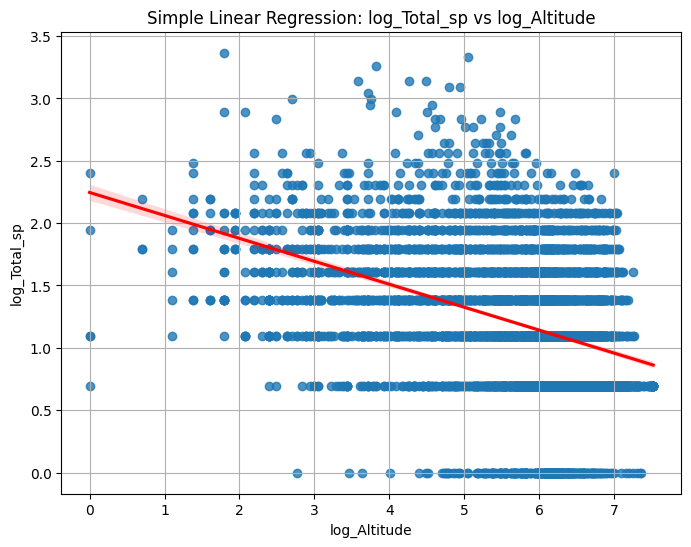


----- Regression for log_Total_sp ~ log_Actual_river_slope -----
                            OLS Regression Results                            
Dep. Variable:           log_Total_sp   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     628.6
Date:                Thu, 14 May 2026   Prob (F-statistic):          9.88e-131
Time:                        13:44:09   Log-Likelihood:                -4131.9
No. Observations:                4975   AIC:                             8268.
Df Residuals:                    4973   BIC:                             8281.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

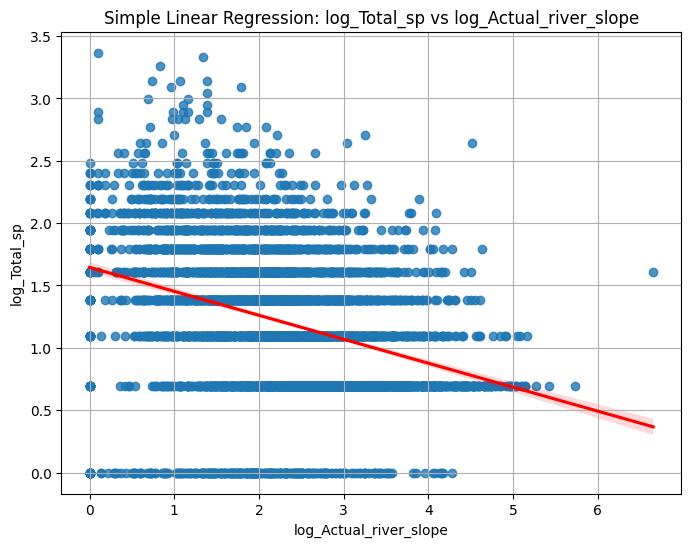


----- Regression for log_Total_sp ~ log_Elevation_mean_catch -----
                            OLS Regression Results                            
Dep. Variable:           log_Total_sp   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     378.0
Date:                Thu, 14 May 2026   Prob (F-statistic):           3.93e-81
Time:                        13:44:10   Log-Likelihood:                -4116.6
No. Observations:                4841   AIC:                             8237.
Df Residuals:                    4839   BIC:                             8250.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

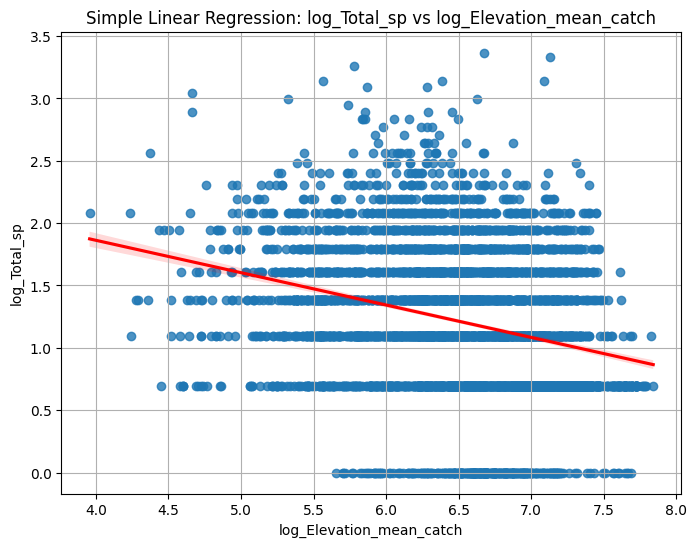


----- Regression for log_Total_sp ~ log_prec_ann_catch -----
                            OLS Regression Results                            
Dep. Variable:           log_Total_sp   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     66.32
Date:                Thu, 14 May 2026   Prob (F-statistic):           4.83e-16
Time:                        13:44:10   Log-Likelihood:                -4265.7
No. Observations:                4841   AIC:                             8535.
Df Residuals:                    4839   BIC:                             8548.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

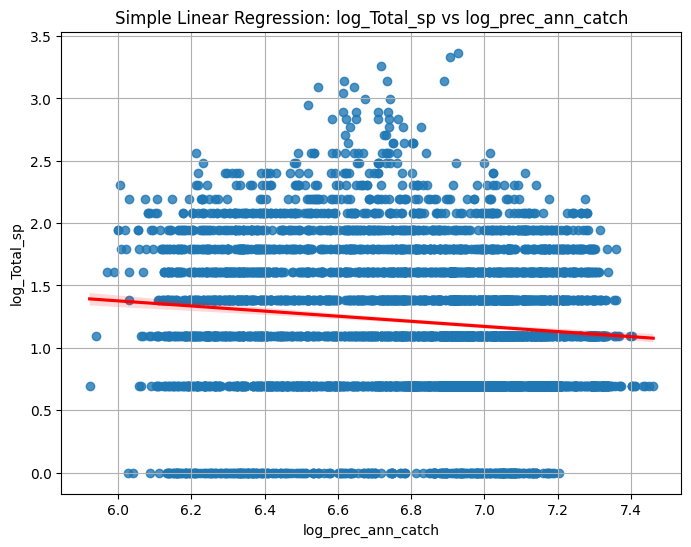


----- Regression for log_Total_sp ~ log_temp_ann -----
                            OLS Regression Results                            
Dep. Variable:           log_Total_sp   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     723.9
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.03e-148
Time:                        13:44:11   Log-Likelihood:                -3961.2
No. Observations:                4841   AIC:                             7926.
Df Residuals:                    4839   BIC:                             7939.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

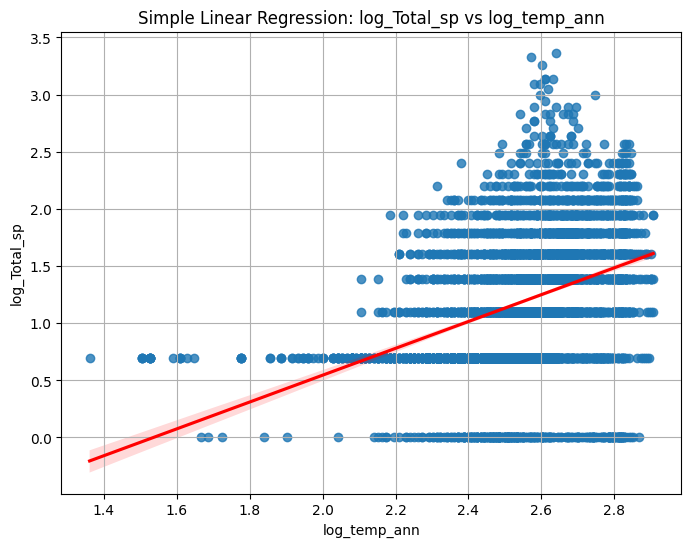


----- Regression for log_Total_sp ~ raw_temp_jan -----
                            OLS Regression Results                            
Dep. Variable:           log_Total_sp   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     463.0
Date:                Thu, 14 May 2026   Prob (F-statistic):           3.78e-98
Time:                        13:44:12   Log-Likelihood:                -4077.5
No. Observations:                4841   AIC:                             8159.
Df Residuals:                    4839   BIC:                             8172.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

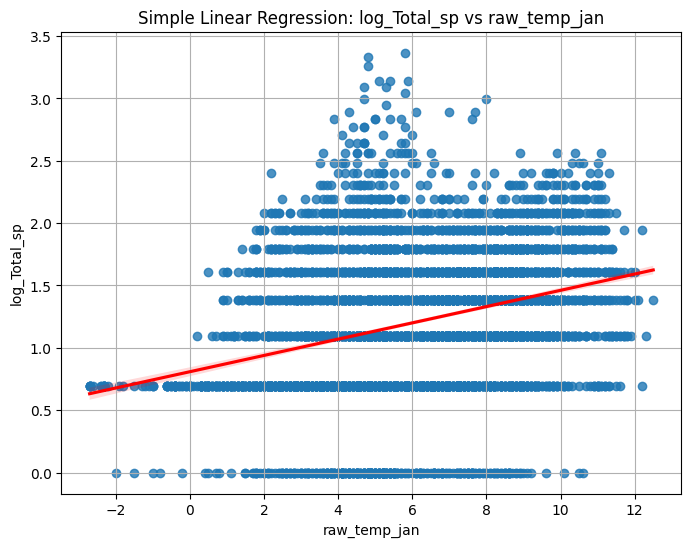


----- Regression for log_Total_sp ~ log_temp_jul -----
                            OLS Regression Results                            
Dep. Variable:           log_Total_sp   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     571.2
Date:                Thu, 14 May 2026   Prob (F-statistic):          2.01e-119
Time:                        13:44:12   Log-Likelihood:                -4028.6
No. Observations:                4841   AIC:                             8061.
Df Residuals:                    4839   BIC:                             8074.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

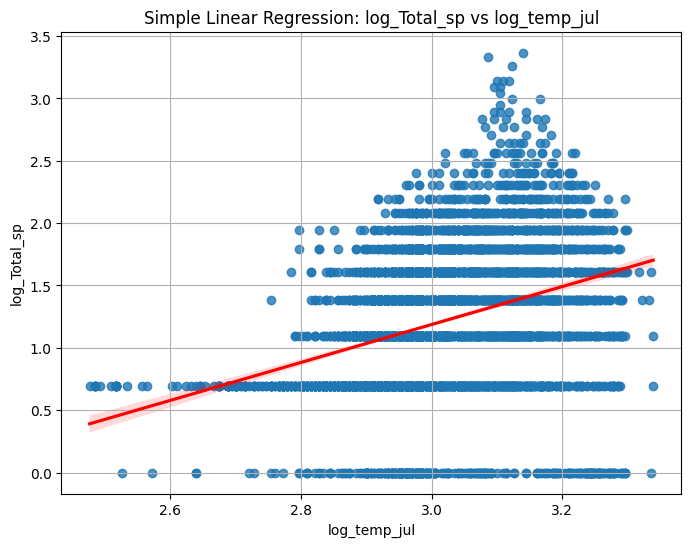

In [ ]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Define the target variable (transformed) and transformed/raw predictor variables
target_variable_transformed = 'log_Total_sp'

# List of transformed/raw predictor variables to use for simple linear regression
# This list comes from the `transformed_predictors` list generated in the previous step
# It should contain 'log_Altitude', 'log_Actual_river_slope', 'log_Elevation_mean_catch',
# 'log_prec_ann_catch', 'log_temp_ann', 'raw_temp_jan', 'log_temp_jul'

print("\n--- Simple Linear Regressions ---")

for predictor in transformed_predictors:
    print(f"\n----- Regression for {target_variable_transformed} ~ {predictor} -----")

    # Prepare data for regression (drop NaNs for the specific variables being used)
    # It's important to use the df_transformed DataFrame for this.
    regression_df = df_transformed[[target_variable_transformed, predictor]].dropna()

    if not regression_df.empty:
        # Build and fit the OLS model
        formula = f'{target_variable_transformed} ~ {predictor}'
        model = smf.ols(formula=formula, data=regression_df)
        results = model.fit()

        # Print summary statistics
        print(results.summary())

        # Plot the fitted model
        plt.figure(figsize=(8, 6))
        sns.regplot(x=predictor, y=target_variable_transformed, data=regression_df, line_kws={'color': 'red'})
        plt.title(f'Simple Linear Regression: {target_variable_transformed} vs {predictor}')
        plt.xlabel(predictor)
        plt.ylabel(target_variable_transformed)
        plt.grid(True)
        plt.show()
    else:
        print(f"No valid data points for regression between {target_variable_transformed} and {predictor} after dropping NaNs.")


--- Multiple Linear Regression ---

Multiple Linear Regression Formula: log_Total_sp ~ log_Altitude + log_Actual_river_slope + log_Elevation_mean_catch + log_prec_ann_catch + log_temp_ann + raw_temp_jan + log_temp_jul
                            OLS Regression Results                            
Dep. Variable:           log_Total_sp   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     216.6
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.57e-280
Time:                        13:44:46   Log-Likelihood:                -3623.8
No. Observations:                4819   AIC:                             7264.
Df Residuals:                    4811   BIC:                             7315.
Df Model:                           7                                         
Covariance Type:            nonrobust                                 

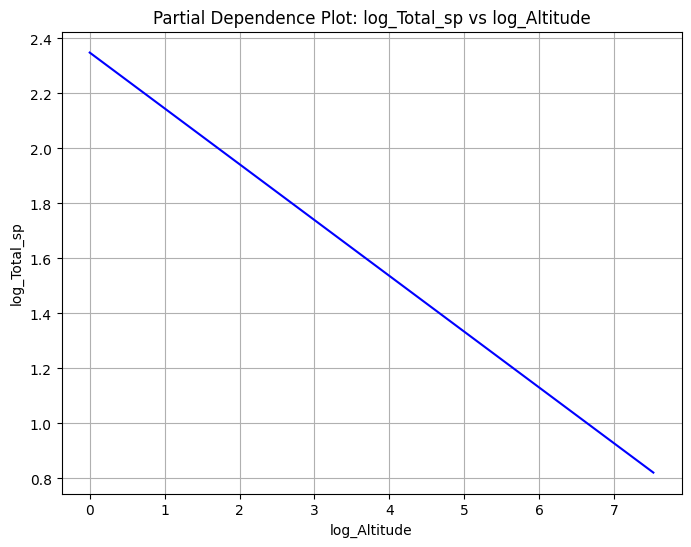

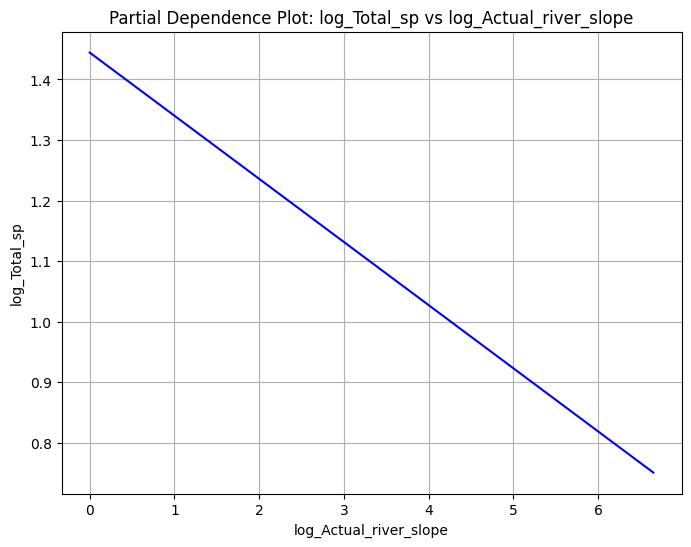

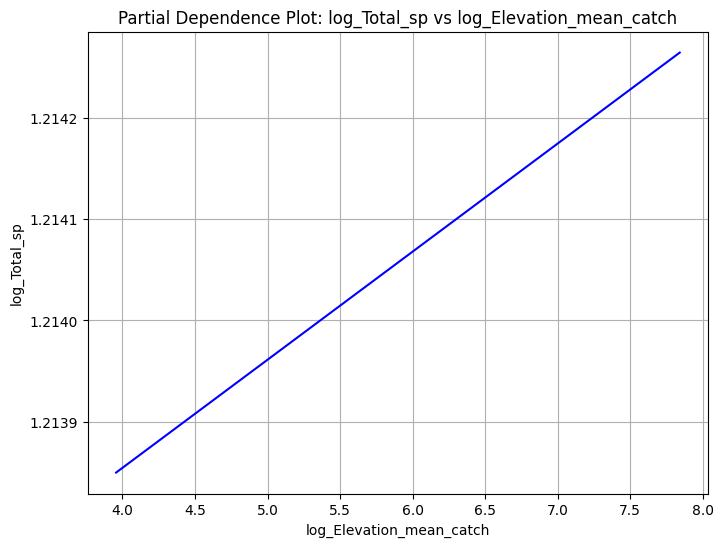

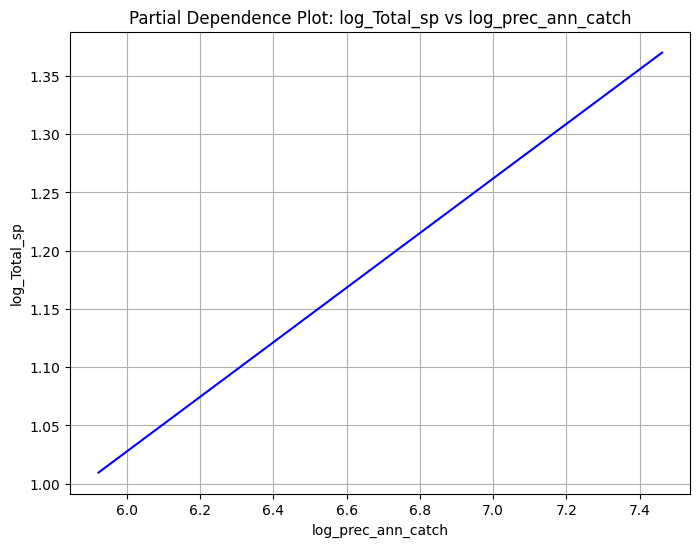

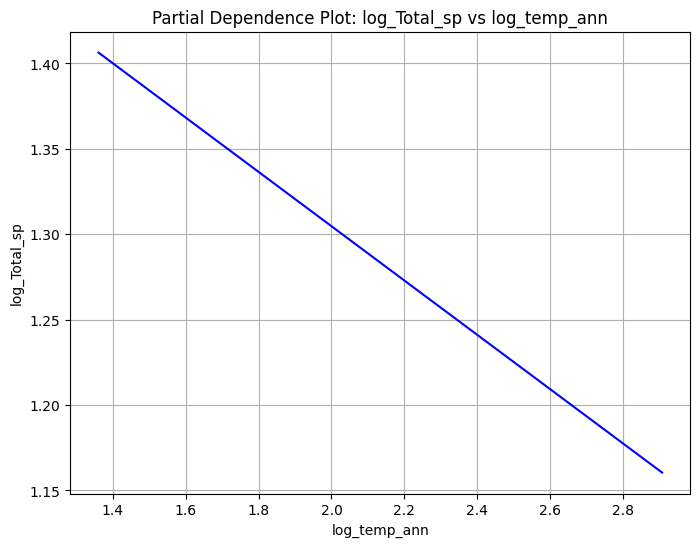

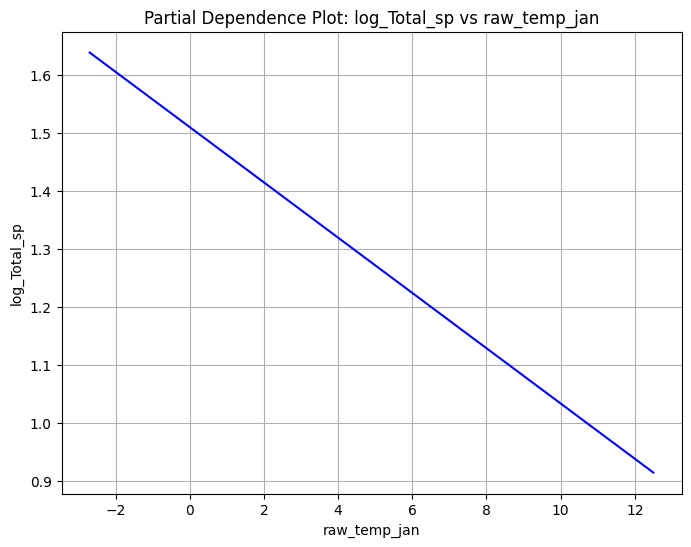

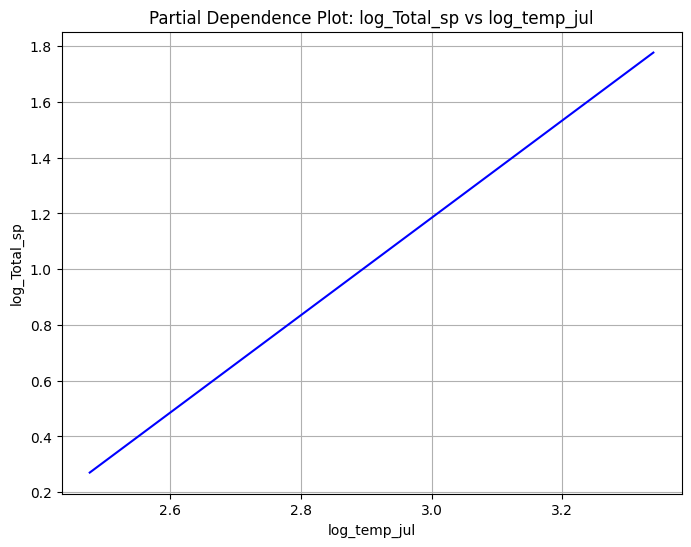

In [ ]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- Multiple Linear Regression ---")

# Define the target variable (transformed) and all transformed/raw predictor variables
target_variable_transformed = 'log_Total_sp'
# `transformed_predictors` was defined in a previous cell and contains the names of the transformed/raw predictor columns

# Prepare the data for multiple regression by dropping rows with any NaNs across all relevant columns
all_columns_for_mlr = [target_variable_transformed] + transformed_predictors
mlr_df = df_transformed[all_columns_for_mlr].dropna()

if not mlr_df.empty:
    # Build the formula for multiple linear regression
    mlr_formula = f'{target_variable_transformed} ~ ' + ' + '.join(transformed_predictors)
    print(f"\nMultiple Linear Regression Formula: {mlr_formula}")

    # Build and fit the OLS model
    mlr_model = smf.ols(formula=mlr_formula, data=mlr_df)
    mlr_results = mlr_model.fit()

    # Print summary statistics for the multiple regression
    print(mlr_results.summary())

    print("\n--- Partial Dependence Plots for Multiple Linear Regression ---")
    # Create partial dependence plots
    for predictor in transformed_predictors:
        plt.figure(figsize=(8, 6))

        # Create a DataFrame for prediction, holding other variables at their mean
        # (or another sensible value if mean is not appropriate, e.g., for categorical)
        pred_df = pd.DataFrame({
            p: [mlr_df[p].mean()] * 100 for p in transformed_predictors if p != predictor
        })

        # Generate a range of values for the current predictor
        min_val = mlr_df[predictor].min()
        max_val = mlr_df[predictor].max()
        pred_df[predictor] = np.linspace(min_val, max_val, 100)

        # Predict using the fitted model
        predictions = mlr_results.predict(pred_df)

        # Plot the partial dependence
        plt.plot(pred_df[predictor], predictions, color='blue')
        plt.title(f'Partial Dependence Plot: {target_variable_transformed} vs {predictor}')
        plt.xlabel(predictor)
        plt.ylabel(target_variable_transformed)
        plt.grid(True)
        plt.show()
else:
    print("No valid data points for multiple linear regression after dropping NaNs.")


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\n--- Checking Multicollinearity with VIF ---")

# Prepare data for VIF calculation
# Ensure we use the same DataFrame as for the multiple linear regression and drop NaNs
# `mlr_df` already contains the clean data subset
X = mlr_df[transformed_predictors]

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by='VIF', ascending=False))

print("\n--- Running a Second More Parsimonious Regression Model ---")

# Based on VIF and p-values from the previous model summary,
# we will create a new model by potentially removing highly collinear variables or those with high p-values.
# Let's consider removing 'log_Elevation_mean_catch' due to its very high p-value (0.997)
# and 'log_temp_ann' which also has a high p-value (0.451) and might be correlated with 'log_temp_jul' or 'raw_temp_jan'.
# Additionally, let's re-check VIF scores before making final exclusions, and for now,
# we'll create a parsimonious model by removing variables with high p-values and very high VIF if present.

# Let's start by removing `log_Elevation_mean_catch` and `log_temp_ann` as they had high p-values
# and then check the new VIFs and coefficients.

parsimonious_predictors = [p for p in transformed_predictors if p not in ['log_Elevation_mean_catch', 'log_temp_ann']]

# Re-check VIFs for the parsimonious set (optional, but good practice)
print("\n--- VIF for Parsimonious Predictors ---")
X_parsimonious = mlr_df[parsimonious_predictors]
vif_data_parsimonious = pd.DataFrame()
vif_data_parsimonious["feature"] = X_parsimonious.columns
vif_data_parsimonious["VIF"] = [variance_inflation_factor(X_parsimonious.values, i) for i in range(X_parsimonious.shape[1])]
print(vif_data_parsimonious.sort_values(by='VIF', ascending=False))


# Build the formula for the parsimonious multiple linear regression
parsimonious_mlr_formula = f'{target_variable_transformed} ~ ' + ' + '.join(parsimonious_predictors)
print(f"\nParsimonious Multiple Linear Regression Formula: {parsimonious_mlr_formula}")

# Build and fit the OLS model
parsimonious_mlr_model = smf.ols(formula=parsimonious_mlr_formula, data=mlr_df)
parsimonious_mlr_results = parsimonious_mlr_model.fit()

# Print summary statistics for the parsimonious multiple regression
print(parsimonious_mlr_results.summary())

print("\n--- Comparison of Coefficients (Full vs. Parsimonious Model) ---")
print("Full Model Coefficients:")
print(mlr_results.params)
print("\nParsimonious Model Coefficients:")
print(parsimonious_mlr_results.params)



--- Checking Multicollinearity with VIF ---
                    feature          VIF
4              log_temp_ann  5204.895865
6              log_temp_jul  4330.778365
2  log_Elevation_mean_catch   461.729295
3        log_prec_ann_catch   271.682990
5              raw_temp_jan   102.441952
0              log_Altitude    72.583227
1    log_Actual_river_slope     7.185894

--- Running a Second More Parsimonious Regression Model ---

--- VIF for Parsimonious Predictors ---
                  feature         VIF
4            log_temp_jul  247.737561
2      log_prec_ann_catch  182.833765
0            log_Altitude   66.672324
3            raw_temp_jan   21.668869
1  log_Actual_river_slope    7.164744

Parsimonious Multiple Linear Regression Formula: log_Total_sp ~ log_Altitude + log_Actual_river_slope + log_prec_ann_catch + raw_temp_jan + log_temp_jul
                            OLS Regression Results                            
Dep. Variable:           log_Total_sp   R-squared:              